# Weekly HMM Regime Model

This notebook fits a separate two-state HMM for AAPL, IBM, and MSFT using weekly log return as the observed series. The numeric state ids do not mean anything on their own, so they are labelled after fitting using training-period returns. The useful output for later notebooks is the causal next-week HMM probability, not a rewritten target label.


## Imports and configuration


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

RANDOM_STATE = 42
N_STATES = 2
HMM_FEATURE_COLS = ["Weekly_Log_Return"]
THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)

MODEL_PATH = Path("outputs/weekly/model_df_weekly.parquet")
OUTPUT_DIR = Path("outputs/weekly_hmm")
PLOT_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_INPUT_COLS = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Weekly_Log_Return",
    "Next_Week_Log_Return",
    "Target_State_Binary",
    "Target_State",
]

print("Input path:", MODEL_PATH)
print("Output directory:", OUTPUT_DIR)
print("HMM feature columns:", HMM_FEATURE_COLS)
print("Threshold grid:", (THRESHOLD_GRID.min(), THRESHOLD_GRID.max(), len(THRESHOLD_GRID)))

Input path: outputs\weekly\model_df_weekly.parquet
Output directory: outputs\weekly_hmm
HMM feature columns: ['Weekly_Log_Return']
Threshold grid: (np.float64(0.05), np.float64(0.95), 91)


## Load weekly modelling data


In [2]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"{MODEL_PATH} was not found. Run LSTM_input_weekly.ipynb first.")

model_df_weekly = pd.read_parquet(MODEL_PATH)
missing_cols = [col for col in REQUIRED_INPUT_COLS if col not in model_df_weekly.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

model_df_weekly = model_df_weekly.copy()
model_df_weekly["Date"] = pd.to_datetime(model_df_weekly["Date"])
model_df_weekly["Target_Date"] = pd.to_datetime(model_df_weekly["Target_Date"])
model_df_weekly["Target_State_Binary"] = model_df_weekly["Target_State_Binary"].astype(int)
model_df_weekly = model_df_weekly.sort_values(["Ticker", "Date"]).reset_index(drop=True)
tickers = sorted(model_df_weekly["Ticker"].unique())

print("Weekly modelling dataframe shape:", model_df_weekly.shape)
print("Tickers:", tickers)
display(model_df_weekly[REQUIRED_INPUT_COLS].head())
display(model_df_weekly.groupby(["Ticker", "Split"]).size().unstack(fill_value=0))
display(model_df_weekly.groupby(["Ticker", "Split", "Target_State"]).size().unstack(fill_value=0))

Weekly modelling dataframe shape: (2424, 29)
Tickers: ['AAPL', 'IBM', 'MSFT']


,Ticker,Date,Target_Date,Split,Weekly_Log_Return,Next_Week_Log_Return,Target_State_Binary,Target_State
0,AAPL,2010-07-09,2010-07-16,train,0.050073,-0.038158,0,Bearish
1,AAPL,2010-07-16,2010-07-23,train,-0.038158,0.039390,1,Bullish
2,AAPL,2010-07-23,2010-07-30,train,0.039390,-0.010402,0,Bearish
3,AAPL,2010-07-30,2010-08-06,train,-0.010402,0.010979,1,Bullish
4,AAPL,2010-08-06,2010-08-13,train,0.010979,-0.043174,0,Bearish


Split,test,train,validation
Ticker,,,
AAPL,122,565,121
IBM,122,565,121
MSFT,122,565,121


Target_State       Bearish  Bullish
Ticker Split                       
AAPL   test             55       67
       train           235      330
       validation       55       66
IBM    test             48       74
       train           269      296
       validation       56       65
MSFT   test             53       69
       train           235      330
       validation       57       64

## Helper functions

The least obvious step is filtering. The forward pass below computes probabilities using only observations up to the current week, so these are causal filtered probabilities rather than smoothed probabilities that peek forward.


In [3]:
def logsumexp_np(values: np.ndarray, axis: int | None = None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    max_values = np.max(values, axis=axis, keepdims=True)
    result = max_values + np.log(np.sum(np.exp(values - max_values), axis=axis, keepdims=True))
    if axis is not None:
        result = np.squeeze(result, axis=axis)
    return result


def filtered_state_probabilities(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Return causal filtered probabilities P(S_t | Y_1:t)."""
    X = np.asarray(X, dtype=float)
    log_likelihood = model._compute_log_likelihood(X)
    eps = np.finfo(float).tiny
    log_startprob = np.log(np.clip(model.startprob_, eps, 1.0))
    log_transmat = np.log(np.clip(model.transmat_, eps, 1.0))

    log_alpha = np.empty_like(log_likelihood)
    # log_alpha[t] stores P(S_t | observations through t), kept in log space.
    log_alpha[0] = log_startprob + log_likelihood[0]
    log_alpha[0] -= logsumexp_np(log_alpha[0])

    for t in range(1, len(X)):
        # Predict one step from t-1 to t, then update with the current observation.
        log_pred = logsumexp_np(log_alpha[t - 1][:, None] + log_transmat, axis=0)
        log_alpha[t] = log_pred + log_likelihood[t]
        log_alpha[t] -= logsumexp_np(log_alpha[t])

    filtered_probs = np.exp(log_alpha)
    filtered_probs /= filtered_probs.sum(axis=1, keepdims=True)
    return filtered_probs


def state_mean_from_training_returns(returns: np.ndarray, states: np.ndarray, probs: np.ndarray, state: int) -> float:
    mask = states == state
    if mask.any():
        return float(np.mean(returns[mask]))
    weights = probs[:, state]
    if np.isclose(weights.sum(), 0):
        return np.nan
    return float(np.average(returns, weights=weights))


def label_hmm_states_using_training_returns(train_returns: np.ndarray, train_states: np.ndarray, train_probs: np.ndarray):
    state_means = {
        state: state_mean_from_training_returns(train_returns, train_states, train_probs, state)
        for state in range(N_STATES)
    }
    sorted_states = sorted(
        state_means,
        key=lambda state: (-np.nan_to_num(state_means[state], nan=-np.inf), state),
    )
    bullish_state = sorted_states[0]
    bearish_state = sorted_states[-1]
    state_to_label = {bullish_state: "Bullish", bearish_state: "Bearish"}
    label_to_state = {label: state for state, label in state_to_label.items()}
    return state_to_label, label_to_state, state_means


def evaluate_binary_classifier(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(y_true) != len(y_prob):
        raise ValueError(f"y_true and y_prob have different lengths: {len(y_true)} != {len(y_prob)}")
    if len(y_true) == 0:
        raise ValueError("Cannot evaluate empty arrays.")

    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "share_predicted_bullish": float(np.mean(y_pred)),
        "share_actual_bullish": float(np.mean(y_true)),
    }
    metrics["roc_auc"] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    return metrics


def select_threshold_by_validation_balanced_accuracy(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray = THRESHOLD_GRID):
    rows = []
    for threshold in thresholds:
        metrics = evaluate_binary_classifier(y_true, y_prob, threshold=float(threshold))
        rows.append(
            {
                "threshold": float(threshold),
                "balanced_accuracy": metrics["balanced_accuracy"],
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "cohen_kappa": metrics["cohen_kappa"],
                "share_predicted_bullish": metrics["share_predicted_bullish"],
                "roc_auc": metrics["roc_auc"],
            }
        )
    threshold_df = pd.DataFrame(rows)
    threshold_df["distance_from_0_5"] = (threshold_df["threshold"] - 0.5).abs()
    best_row = threshold_df.sort_values(["balanced_accuracy", "distance_from_0_5"], ascending=[False, True]).iloc[0]
    return float(best_row["threshold"]), float(best_row["balanced_accuracy"]), threshold_df.drop(columns="distance_from_0_5")


def expected_duration(self_transition_probability: float) -> float:
    if np.isclose(1 - self_transition_probability, 0):
        return np.inf
    return float(1 / (1 - self_transition_probability))


def volatility_diagnostic(mean_gap: float, volatility_gap: float) -> str:
    if volatility_gap > abs(mean_gap):
        return "Volatility difference is larger than mean-return difference; regimes may be calm/stress rather than strictly bullish/bearish."
    return "Mean-return difference is at least as large as volatility difference; bullish/bearish interpretation is more directly supported."


## Fit one HMM per ticker

Each stock gets its own two-state Gaussian HMM. The main observed input is weekly log return. After fitting, the states are labelled using only the training sample; the labels are best read as relative bullish/bearish or calm/stress states, not literal market regimes.


In [4]:
hmm_feature_frames = []
state_summary_rows = []
transition_rows = []
duration_rows = []
model_diagnostic_rows = []
scaler_rows = []

for ticker in tickers:
    ticker_df = model_df_weekly.loc[model_df_weekly["Ticker"] == ticker].sort_values("Date").copy()
    train_mask = ticker_df["Split"] == "train"
    if train_mask.sum() < 50:
        raise ValueError(f"Ticker {ticker} has too few training rows for HMM fitting: {train_mask.sum()}")

    scaler = StandardScaler()
    X_train = ticker_df.loc[train_mask, HMM_FEATURE_COLS].to_numpy(dtype=float)
    X_all = ticker_df[HMM_FEATURE_COLS].to_numpy(dtype=float)
    # Scale and fit using the training period only.
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_all_scaled = scaler.transform(X_all)
    scaler_rows.append(
        {
            "Ticker": ticker,
            "Feature": HMM_FEATURE_COLS[0],
            "Train_Mean": float(scaler.mean_[0]),
            "Train_Scale": float(scaler.scale_[0]),
            "Fitted_On": "train",
        }
    )

    hmm = GaussianHMM(
        n_components=N_STATES,
        covariance_type="full",
        n_iter=500,
        tol=1e-4,
        random_state=RANDOM_STATE,
        min_covar=1e-4,
    )
    hmm.fit(X_train_scaled)

    # Filtered probabilities describe the current state using history through this week.
    filtered_probs = filtered_state_probabilities(hmm, X_all_scaled)
    # Multiplying by the transition matrix gives one-week-ahead state probabilities.
    next_probs = filtered_probs @ hmm.transmat_
    hard_states = filtered_probs.argmax(axis=1)

    train_positions = np.flatnonzero(train_mask.to_numpy())
    train_returns = ticker_df.loc[train_mask, "Weekly_Log_Return"].to_numpy(dtype=float)
    train_states = hard_states[train_positions]
    train_probs = filtered_probs[train_positions]
    # HMM state numbers are arbitrary, so label them after fitting using training returns.
    state_to_label, label_to_state, train_state_means = label_hmm_states_using_training_returns(train_returns, train_states, train_probs)
    bullish_state = label_to_state["Bullish"]
    bearish_state = label_to_state["Bearish"]

    train_state_df = ticker_df.loc[train_mask].copy()
    train_state_df["HMM_State"] = train_states
    train_state_df["Current_Return_Positive"] = (train_state_df["Weekly_Log_Return"] > 0).astype(int)
    state_positive_probs = train_state_df.groupby("HMM_State")["Current_Return_Positive"].mean().to_dict()
    state_positive_probs = {int(state): float(prob) for state, prob in state_positive_probs.items()}

    hmm_positive_return_prob_next = (
        next_probs[:, 0] * state_positive_probs.get(0, 0.5)
        + next_probs[:, 1] * state_positive_probs.get(1, 0.5)
    )

    ticker_hmm_df = ticker_df.copy()
    ticker_hmm_df["HMM_State"] = hard_states.astype(int)
    ticker_hmm_df["HMM_Regime_Label"] = ticker_hmm_df["HMM_State"].map(state_to_label)
    ticker_hmm_df["HMM_Bullish_Prob"] = filtered_probs[:, bullish_state]
    ticker_hmm_df["HMM_Bearish_Prob"] = filtered_probs[:, bearish_state]
    ticker_hmm_df["HMM_Bullish_Prob_Next"] = next_probs[:, bullish_state]
    ticker_hmm_df["HMM_Bearish_Prob_Next"] = next_probs[:, bearish_state]
    ticker_hmm_df["HMM_Positive_Return_Prob_Next"] = hmm_positive_return_prob_next
    hmm_feature_frames.append(ticker_hmm_df)

    train_state_summary = (
        ticker_hmm_df.loc[train_mask]
        .groupby("HMM_State")["Weekly_Log_Return"]
        .agg(["count", "mean", "std"])
        .reindex(range(N_STATES))
    )
    state_mean_values = []
    state_vol_values = []
    for state in range(N_STATES):
        label = state_to_label[state]
        train_count = int(train_state_summary.loc[state, "count"]) if pd.notna(train_state_summary.loc[state, "count"]) else 0
        train_mean = float(train_state_summary.loc[state, "mean"]) if pd.notna(train_state_summary.loc[state, "mean"]) else float(train_state_means[state])
        train_std = float(train_state_summary.loc[state, "std"]) if pd.notna(train_state_summary.loc[state, "std"]) else np.nan
        state_mean_values.append(train_mean)
        state_vol_values.append(train_std)
        state_summary_rows.append(
            {
                "Ticker": ticker,
                "HMM_State": state,
                "Regime_Label": label,
                "Train_State_Count": train_count,
                "Train_Mean_Weekly_Log_Return": train_mean,
                "Train_Std_Weekly_Log_Return": train_std,
                "Train_Positive_Return_Probability": state_positive_probs.get(state, 0.5),
                "Emission_Mean_Scaled": float(hmm.means_[state, 0]),
                "Emission_Variance_Scaled": float(hmm.covars_[state].reshape(-1)[0]),
                "Labelled_Using": "training mean Weekly_Log_Return",
                "Positive_Return_Probability_Estimated_On": "train",
            }
        )

    mean_gap = float(max(state_mean_values) - min(state_mean_values))
    finite_vol_values = [v for v in state_vol_values if pd.notna(v)]
    volatility_gap = float(max(finite_vol_values) - min(finite_vol_values)) if len(finite_vol_values) == 2 else np.nan
    model_diagnostic_rows.append(
        {
            "Ticker": ticker,
            "Train_Log_Likelihood": float(hmm.score(X_train_scaled)),
            "Converged": bool(hmm.monitor_.converged),
            "Iterations": int(hmm.monitor_.iter),
            "Bullish_State": int(bullish_state),
            "Bearish_State": int(bearish_state),
            "Training_Mean_Return_Gap": mean_gap,
            "Training_Volatility_Gap": volatility_gap,
            "Regime_Diagnostic_Comment": volatility_diagnostic(mean_gap, volatility_gap),
            "Scaler_Fitted_On": "train",
            "HMM_Fitted_On": "train",
            "Positive_Return_Probability_Estimated_On": "train",
        }
    )

    for from_state in range(N_STATES):
        for to_state in range(N_STATES):
            transition_rows.append(
                {
                    "Ticker": ticker,
                    "From_State": from_state,
                    "To_State": to_state,
                    "From_Label": state_to_label[from_state],
                    "To_Label": state_to_label[to_state],
                    "Transition_Probability": float(hmm.transmat_[from_state, to_state]),
                }
            )
    for state in range(N_STATES):
        self_prob = float(hmm.transmat_[state, state])
        duration_rows.append(
            {
                "Ticker": ticker,
                "HMM_State": state,
                "Regime_Label": state_to_label[state],
                "Self_Transition_Probability": self_prob,
                "Expected_Duration_Weeks": expected_duration(self_prob),
            }
        )

weekly_hmm_features_df = pd.concat(hmm_feature_frames, ignore_index=True)
weekly_hmm_state_summary_df = pd.DataFrame(state_summary_rows)
weekly_hmm_transition_df = pd.DataFrame(transition_rows)
weekly_hmm_duration_df = pd.DataFrame(duration_rows)
weekly_hmm_model_diagnostics_df = pd.DataFrame(model_diagnostic_rows)
weekly_hmm_scaler_metadata_df = pd.DataFrame(scaler_rows)

print("Weekly HMM feature dataframe shape:", weekly_hmm_features_df.shape)
display(weekly_hmm_state_summary_df.sort_values(["Ticker", "Regime_Label"]))
display(weekly_hmm_transition_df.sort_values(["Ticker", "From_State", "To_State"]))
display(weekly_hmm_duration_df.sort_values(["Ticker", "Regime_Label"]))
display(weekly_hmm_model_diagnostics_df)


Weekly HMM feature dataframe shape: (2424, 36)


,Ticker,HMM_State,Regime_Label,Train_State_Count,Train_Mean_Weekly_Log_Return,Train_Std_Weekly_Log_Return,Train_Positive_Return_Probability,Emission_Mean_Scaled,Emission_Variance_Scaled,Labelled_Using,Positive_Return_Probability_Estimated_On
1,AAPL,1,Bearish,233,-0.002675,0.053135,0.454936,-0.172955,1.599511,training mean Weekly_Log_Return,train
0,AAPL,0,Bullish,332,0.010464,0.022468,0.677711,0.152103,0.423392,training mean Weekly_Log_Return,train
3,IBM,1,Bearish,135,-0.003020,0.055461,0.488889,-0.141653,2.475032,training mean Weekly_Log_Return,train
2,IBM,0,Bullish,430,0.002114,0.016923,0.534884,0.060474,0.358112,training mean Weekly_Log_Return,train
5,MSFT,1,Bearish,75,-0.003555,0.064891,0.453333,-0.133437,2.735446,training mean Weekly_Log_Return,train
4,MSFT,0,Bullish,490,0.005903,0.021482,0.604082,0.038555,0.491982,training mean Weekly_Log_Return,train


,Ticker,From_State,To_State,From_Label,To_Label,Transition_Probability
0,AAPL,0,0,Bullish,Bullish,0.905671
1,AAPL,0,1,Bullish,Bearish,0.094329
2,AAPL,1,0,Bearish,Bullish,0.105819
3,AAPL,1,1,Bearish,Bearish,0.894181
4,IBM,0,0,Bullish,Bullish,0.908799
5,IBM,0,1,Bullish,Bearish,0.091201
6,IBM,1,0,Bearish,Bullish,0.216870
7,IBM,1,1,Bearish,Bearish,0.783130
8,MSFT,0,0,Bullish,Bullish,0.918111
9,MSFT,0,1,Bullish,Bearish,0.081889


,Ticker,HMM_State,Regime_Label,Self_Transition_Probability,Expected_Duration_Weeks
1,AAPL,1,Bearish,0.894181,9.450055
0,AAPL,0,Bullish,0.905671,10.601217
3,IBM,1,Bearish,0.783130,4.611056
2,IBM,0,Bullish,0.908799,10.964770
5,MSFT,1,Bearish,0.718421,3.551404
4,MSFT,0,Bullish,0.918111,12.211697


,Ticker,Train_Log_Likelihood,Converged,Iterations,Bullish_State,Bearish_State,Training_Mean_Return_Gap,Training_Volatility_Gap,Regime_Diagnostic_Comment,Scaler_Fitted_On,HMM_Fitted_On,Positive_Return_Probability_Estimated_On
0,AAPL,-778.262463,True,135,0,1,0.013139,0.030667,Volatility difference is larger than mean-retu...,train,train,train
1,IBM,-742.978249,True,63,0,1,0.005133,0.038538,Volatility difference is larger than mean-retu...,train,train,train
2,MSFT,-762.080154,True,121,0,1,0.009458,0.043409,Volatility difference is larger than mean-retu...,train,train,train


## HMM-only next-week classifier

The corrected HMM-only classifier uses `HMM_Positive_Return_Prob_Next`, not `HMM_Bullish_Prob_Next`, as the probability score. This converts next-step regime probabilities into a probability that the next weekly return is positive.

The decision threshold is selected on validation data only by maximizing validation balanced accuracy. Test data is never used to choose the threshold.

In [5]:
def benchmark_probability(df: pd.DataFrame, model_name: str, majority_class: int | None = None) -> np.ndarray:
    if model_name == "majority_class":
        if majority_class is None:
            raise ValueError("majority_class must be provided for the majority-class benchmark.")
        return np.full(len(df), fill_value=float(majority_class), dtype=float)
    if model_name == "always_bullish":
        return np.ones(len(df), dtype=float)
    if model_name == "always_bearish":
        return np.zeros(len(df), dtype=float)
    if model_name == "persistence":
        return (df["Weekly_Log_Return"].to_numpy(dtype=float) > 0).astype(float)
    raise ValueError(f"Unknown benchmark model: {model_name}")


hmm_result_rows = []
hmm_prediction_frames = []
hmm_threshold_frames = []
benchmark_models = ["majority_class", "always_bullish", "always_bearish", "persistence"]

for ticker in tickers:
    ticker_df = weekly_hmm_features_df.loc[weekly_hmm_features_df["Ticker"] == ticker].sort_values("Date").copy()
    train_df = ticker_df.loc[ticker_df["Split"] == "train"].copy()
    val_df = ticker_df.loc[ticker_df["Split"] == "validation"].copy()
    test_df = ticker_df.loc[ticker_df["Split"] == "test"].copy()
    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(f"Ticker {ticker} has an empty split.")

    majority_class = int(train_df["Target_State_Binary"].mean() >= 0.5)
    y_val = val_df["Target_State_Binary"].to_numpy(dtype=int)
    y_test = test_df["Target_State_Binary"].to_numpy(dtype=int)
    val_prob = val_df["HMM_Positive_Return_Prob_Next"].to_numpy(dtype=float)
    test_prob = test_df["HMM_Positive_Return_Prob_Next"].to_numpy(dtype=float)

    decision_threshold, best_val_balanced_accuracy, threshold_search_df = select_threshold_by_validation_balanced_accuracy(y_val, val_prob)
    threshold_search_df.insert(0, "Ticker", ticker)
    threshold_search_df.insert(1, "Probability_Column", "HMM_Positive_Return_Prob_Next")
    hmm_threshold_frames.append(threshold_search_df)

    val_metrics = evaluate_binary_classifier(y_val, val_prob, threshold=decision_threshold)
    test_metrics = evaluate_binary_classifier(y_test, test_prob, threshold=decision_threshold)
    hmm_result_rows.append(
        {
            "Ticker": ticker,
            "Model": "weekly_hmm_only",
            "Probability_Column": "HMM_Positive_Return_Prob_Next",
            "Decision_Threshold": decision_threshold,
            "Best_Val_Threshold_Balanced_Accuracy": best_val_balanced_accuracy,
            "Train_Rows": len(train_df),
            "Validation_Rows": len(val_df),
            "Test_Rows": len(test_df),
            **{f"Val_{key}": value for key, value in val_metrics.items()},
            **{f"Test_{key}": value for key, value in test_metrics.items()},
        }
    )

    for split_name, split_df, y_true, y_prob in [
        ("validation", val_df, y_val, val_prob),
        ("test", test_df, y_test, test_prob),
    ]:
        hmm_prediction_frames.append(
            pd.DataFrame(
                {
                    "Ticker": ticker,
                    "Model": "weekly_hmm_only",
                    "Probability_Column": "HMM_Positive_Return_Prob_Next",
                    "Split": split_name,
                    "Date": split_df["Date"].to_numpy(),
                    "Target_Date": split_df["Target_Date"].to_numpy(),
                    "Decision_Threshold": decision_threshold,
                    "y_true": y_true,
                    "y_prob": y_prob,
                    "y_pred": (y_prob >= decision_threshold).astype(int),
                }
            )
        )

    for model_name in benchmark_models:
        val_benchmark_prob = benchmark_probability(val_df, model_name, majority_class=majority_class)
        test_benchmark_prob = benchmark_probability(test_df, model_name, majority_class=majority_class)
        val_benchmark_metrics = evaluate_binary_classifier(y_val, val_benchmark_prob, threshold=0.5)
        test_benchmark_metrics = evaluate_binary_classifier(y_test, test_benchmark_prob, threshold=0.5)
        hmm_result_rows.append(
            {
                "Ticker": ticker,
                "Model": model_name,
                "Probability_Column": "benchmark_rule",
                "Decision_Threshold": 0.5,
                "Best_Val_Threshold_Balanced_Accuracy": val_benchmark_metrics["balanced_accuracy"],
                "Train_Rows": len(train_df),
                "Validation_Rows": len(val_df),
                "Test_Rows": len(test_df),
                **{f"Val_{key}": value for key, value in val_benchmark_metrics.items()},
                **{f"Test_{key}": value for key, value in test_benchmark_metrics.items()},
            }
        )

weekly_hmm_only_results_df = pd.DataFrame(hmm_result_rows)
weekly_hmm_only_predictions_df = pd.concat(hmm_prediction_frames, ignore_index=True)
weekly_hmm_threshold_search_df = pd.concat(hmm_threshold_frames, ignore_index=True)

print("Corrected HMM-only results:")
display(weekly_hmm_only_results_df.sort_values(["Ticker", "Model"]))
print("Best validation thresholds for corrected HMM-only classifier:")
display(weekly_hmm_only_results_df.loc[weekly_hmm_only_results_df["Model"] == "weekly_hmm_only", ["Ticker", "Probability_Column", "Decision_Threshold", "Best_Val_Threshold_Balanced_Accuracy", "Test_balanced_accuracy", "Test_roc_auc"]])

Corrected HMM-only results:


,Ticker,Model,Probability_Column,Decision_Threshold,Best_Val_Threshold_Balanced_Accuracy,Train_Rows,Validation_Rows,Test_Rows,Val_accuracy,Val_balanced_accuracy,Val_f1,Val_cohen_kappa,Val_share_predicted_bullish,Val_share_actual_bullish,Val_roc_auc,Val_tn,Val_fp,Val_fn,Val_tp,Test_accuracy,Test_balanced_accuracy,Test_f1,Test_cohen_kappa,Test_share_predicted_bullish,Test_share_actual_bullish,Test_roc_auc,Test_tn,Test_fp,Test_fn,Test_tp
3,AAPL,always_bearish,benchmark_rule,0.5,0.500000,565,121,122,0.454545,0.500000,0.000000,0.000000,0.000000,0.545455,0.500000,55,0,66,0,0.450820,0.500000,0.000000,0.000000,0.000000,0.549180,0.500000,55,0,67,0
2,AAPL,always_bullish,benchmark_rule,0.5,0.500000,565,121,122,0.545455,0.500000,0.705882,0.000000,1.000000,0.545455,0.500000,0,55,0,66,0.549180,0.500000,0.708995,0.000000,1.000000,0.549180,0.500000,0,55,0,67
1,AAPL,majority_class,benchmark_rule,0.5,0.500000,565,121,122,0.545455,0.500000,0.705882,0.000000,1.000000,0.545455,0.500000,0,55,0,66,0.549180,0.500000,0.708995,0.000000,1.000000,0.549180,0.500000,0,55,0,67
4,AAPL,persistence,benchmark_rule,0.5,0.559091,565,121,122,0.561983,0.559091,0.595420,0.118003,0.537190,0.545455,0.559091,29,26,27,39,0.483607,0.477748,0.533333,-0.044577,0.557377,0.549180,0.477748,23,32,31,36
0,AAPL,weekly_hmm_only,HMM_Positive_Return_Prob_Next,0.6,0.639394,565,121,122,0.628099,0.639394,0.601770,0.270987,0.388430,0.545455,0.625895,42,13,32,34,0.434426,0.450882,0.355140,-0.094099,0.327869,0.549180,0.437449,34,21,48,19
8,IBM,always_bearish,benchmark_rule,0.5,0.500000,565,121,122,0.462810,0.500000,0.000000,0.000000,0.000000,0.537190,0.500000,56,0,65,0,0.393443,0.500000,0.000000,0.000000,0.000000,0.606557,0.500000,48,0,74,0
7,IBM,always_bullish,benchmark_rule,0.5,0.500000,565,121,122,0.537190,0.500000,0.698925,0.000000,1.000000,0.537190,0.500000,0,56,0,65,0.606557,0.500000,0.755102,0.000000,1.000000,0.606557,0.500000,0,48,0,74
6,IBM,majority_class,benchmark_rule,0.5,0.500000,565,121,122,0.537190,0.500000,0.698925,0.000000,1.000000,0.537190,0.500000,0,56,0,65,0.606557,0.500000,0.755102,0.000000,1.000000,0.606557,0.500000,0,48,0,74
9,IBM,persistence,benchmark_rule,0.5,0.484753,565,121,122,0.487603,0.484753,0.523077,-0.030495,0.537190,0.537190,0.484753,25,31,31,34,0.516393,0.491554,0.604027,-0.016954,0.614754,0.606557,0.491554,18,30,29,45
5,IBM,weekly_hmm_only,HMM_Positive_Return_Prob_Next,0.5,0.512637,565,121,122,0.545455,0.512637,0.692737,0.026905,0.942149,0.537190,0.480769,4,52,3,62,0.639344,0.552646,0.763441,0.122302,0.918033,0.606557,0.539414,7,41,3,71


Best validation thresholds for corrected HMM-only classifier:


,Ticker,Probability_Column,Decision_Threshold,Best_Val_Threshold_Balanced_Accuracy,Test_balanced_accuracy,Test_roc_auc
0,AAPL,HMM_Positive_Return_Prob_Next,0.6,0.639394,0.450882,0.437449
5,IBM,HMM_Positive_Return_Prob_Next,0.5,0.512637,0.552646,0.539414
10,MSFT,HMM_Positive_Return_Prob_Next,0.5,0.536047,0.487695,0.452830


## Save weekly HMM outputs


In [6]:
weekly_hmm_regime_features_path = OUTPUT_DIR / "weekly_hmm_regime_features.parquet"
weekly_hmm_state_summary_path = OUTPUT_DIR / "weekly_hmm_state_summary.csv"
weekly_hmm_transition_path = OUTPUT_DIR / "weekly_hmm_transition_matrices.csv"
weekly_hmm_duration_path = OUTPUT_DIR / "weekly_hmm_expected_durations.csv"
weekly_hmm_results_path = OUTPUT_DIR / "weekly_hmm_only_results.csv"
weekly_hmm_predictions_path = OUTPUT_DIR / "weekly_hmm_only_predictions.csv"
weekly_hmm_threshold_path = OUTPUT_DIR / "weekly_hmm_threshold_search.csv"
weekly_hmm_diagnostics_path = OUTPUT_DIR / "weekly_hmm_model_diagnostics.csv"
weekly_hmm_scaler_metadata_path = OUTPUT_DIR / "weekly_hmm_scaler_metadata.csv"

weekly_hmm_features_df.to_parquet(weekly_hmm_regime_features_path, index=False)
weekly_hmm_state_summary_df.to_csv(weekly_hmm_state_summary_path, index=False)
weekly_hmm_transition_df.to_csv(weekly_hmm_transition_path, index=False)
weekly_hmm_duration_df.to_csv(weekly_hmm_duration_path, index=False)
weekly_hmm_only_results_df.to_csv(weekly_hmm_results_path, index=False)
weekly_hmm_only_predictions_df.to_csv(weekly_hmm_predictions_path, index=False)
weekly_hmm_threshold_search_df.to_csv(weekly_hmm_threshold_path, index=False)
weekly_hmm_model_diagnostics_df.to_csv(weekly_hmm_diagnostics_path, index=False)
weekly_hmm_scaler_metadata_df.to_csv(weekly_hmm_scaler_metadata_path, index=False)

saved_output_paths = [
    weekly_hmm_regime_features_path,
    weekly_hmm_state_summary_path,
    weekly_hmm_transition_path,
    weekly_hmm_duration_path,
    weekly_hmm_results_path,
    weekly_hmm_predictions_path,
    weekly_hmm_threshold_path,
    weekly_hmm_diagnostics_path,
    weekly_hmm_scaler_metadata_path,
]
print("Saved weekly HMM outputs:")
for output_path in saved_output_paths:
    print(output_path)

Saved weekly HMM outputs:
outputs\weekly_hmm\weekly_hmm_regime_features.parquet
outputs\weekly_hmm\weekly_hmm_state_summary.csv
outputs\weekly_hmm\weekly_hmm_transition_matrices.csv
outputs\weekly_hmm\weekly_hmm_expected_durations.csv
outputs\weekly_hmm\weekly_hmm_only_results.csv
outputs\weekly_hmm\weekly_hmm_only_predictions.csv
outputs\weekly_hmm\weekly_hmm_threshold_search.csv
outputs\weekly_hmm\weekly_hmm_model_diagnostics.csv
outputs\weekly_hmm\weekly_hmm_scaler_metadata.csv


## Plots


Saved plot: outputs\weekly_hmm\plots\weekly_hmm_bullish_regime_probability_over_time.png


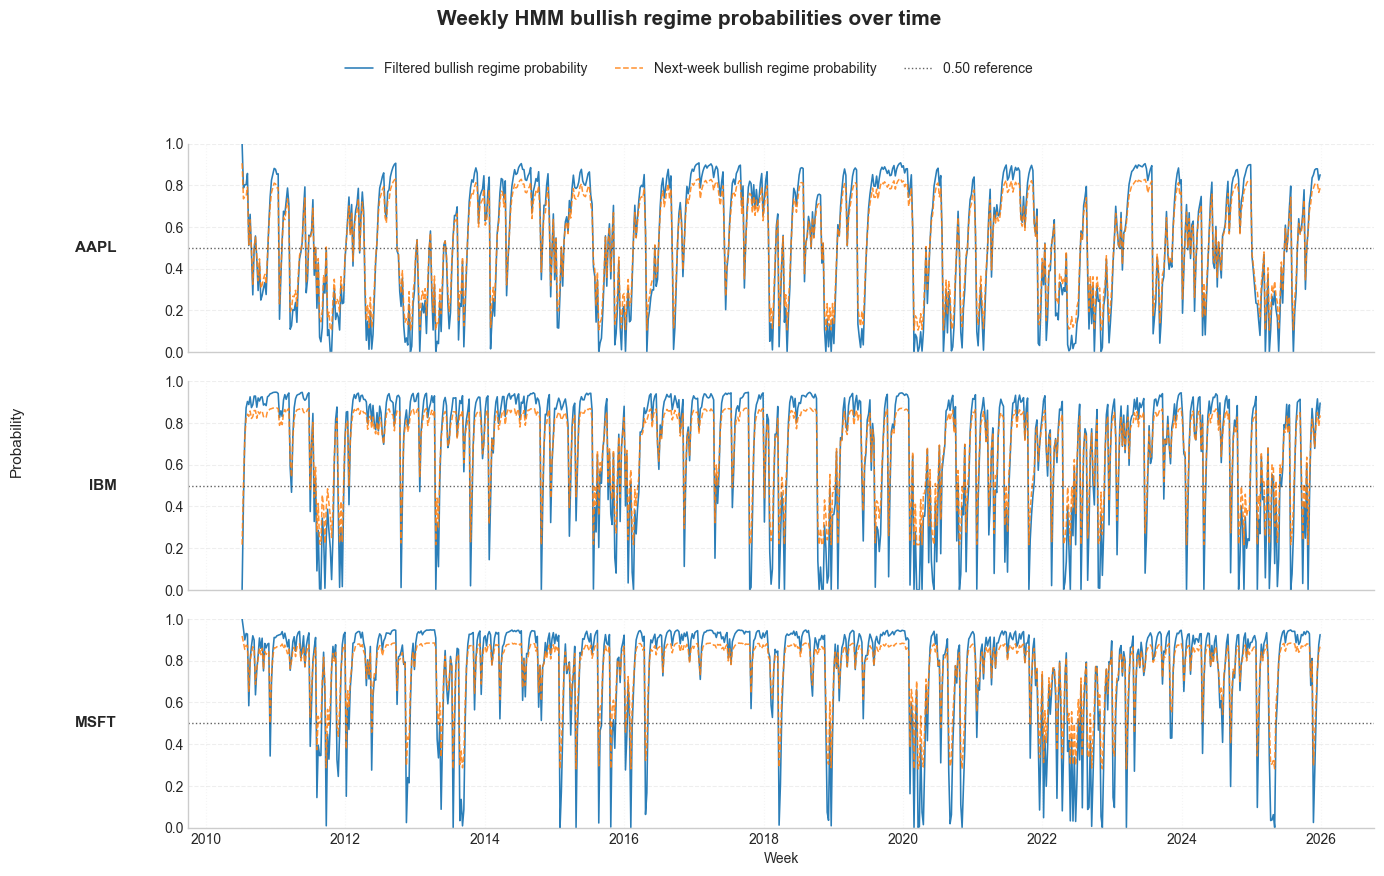

Saved plot: outputs\weekly_hmm\plots\weekly_hmm_positive_return_probability_over_time.png


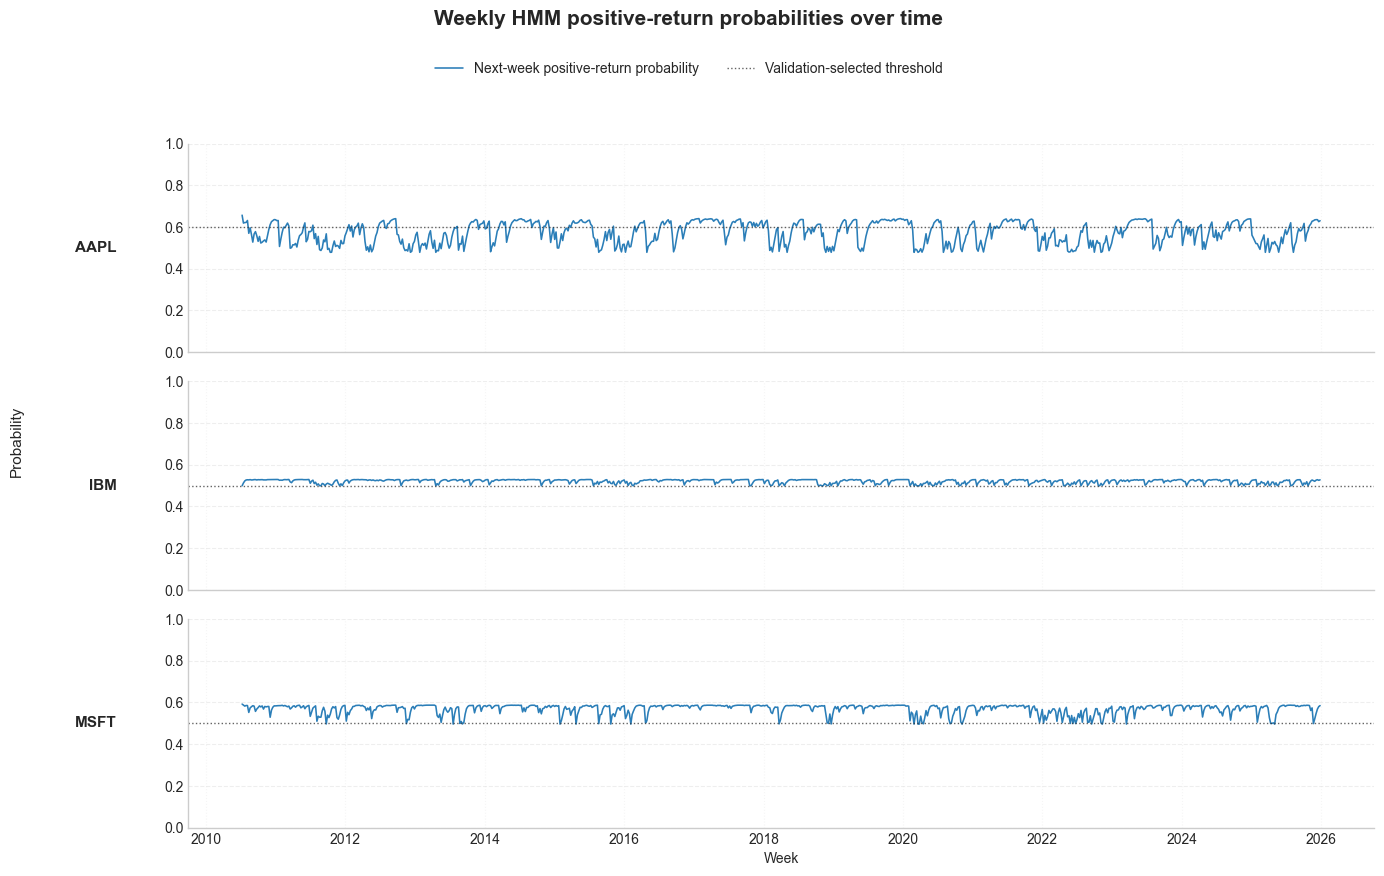

C:\Users\Admin\AppData\Local\Temp\ipykernel_16588\1194638060.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(groups, labels=["Bearish", "Bullish"], patch_artist=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16588\1194638060.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(groups, labels=["Bearish", "Bullish"], patch_artist=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16588\1194638060.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(groups, labels=["Bearish", "Bullish"], patch_artist=True)


Saved plot: outputs\weekly_hmm\plots\weekly_returns_by_hmm_regime.png


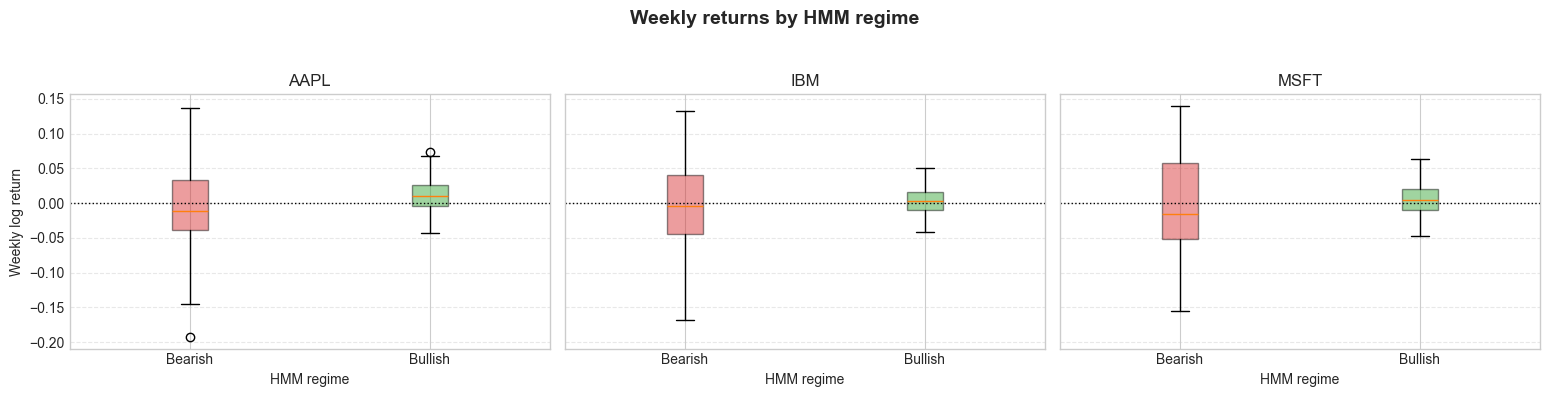

Saved plot: outputs\weekly_hmm\plots\weekly_hmm_transition_matrices.png


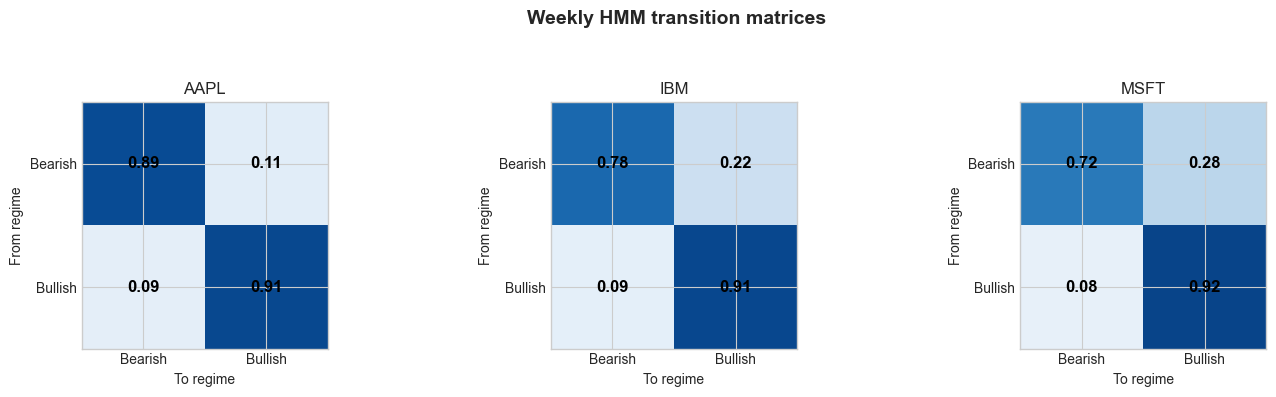

Saved plot: outputs\weekly_hmm\plots\weekly_hmm_only_confusion_matrices.png


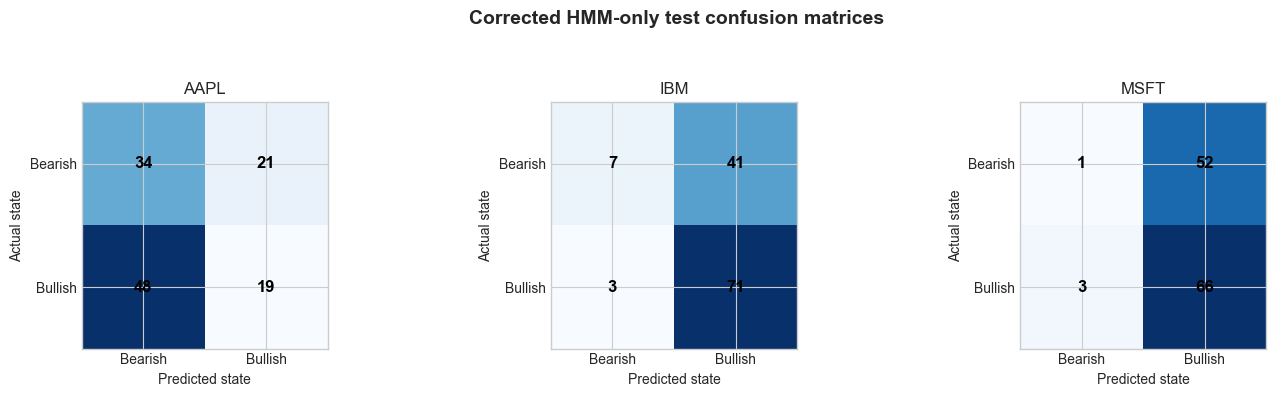

Saved plot: outputs\weekly_hmm\plots\weekly_hmm_only_roc_curves.png


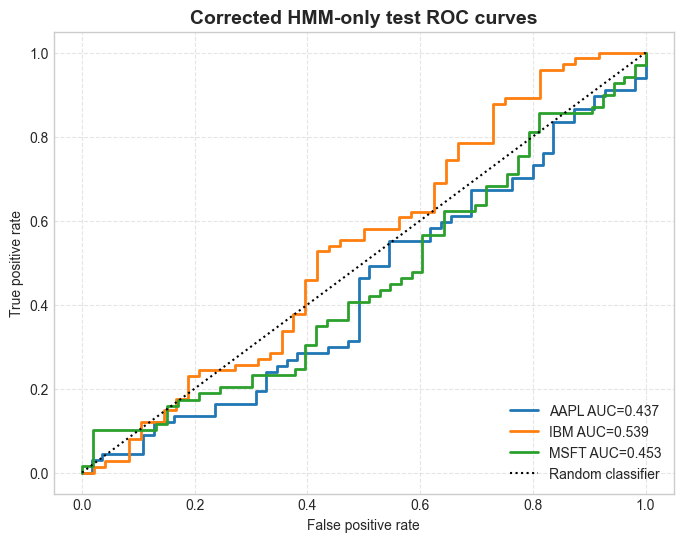

In [7]:
saved_plot_paths = []
EXPECTED_PLOT_FILES = [
    PLOT_DIR / "weekly_hmm_bullish_regime_probability_over_time.png",
    PLOT_DIR / "weekly_hmm_positive_return_probability_over_time.png",
    PLOT_DIR / "weekly_returns_by_hmm_regime.png",
    PLOT_DIR / "weekly_hmm_transition_matrices.png",
    PLOT_DIR / "weekly_hmm_only_confusion_matrices.png",
    PLOT_DIR / "weekly_hmm_only_roc_curves.png",
]


def save_plot(filename: str) -> Path:
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    saved_plot_paths.append(path)
    print(f"Saved plot: {path}")
    return path


# 1. HMM bullish regime probability over time per ticker
probability_plot_style = {
    "filtered": {"color": "#1f77b4", "linewidth": 1.15, "alpha": 0.95},
    "next": {"color": "#ff7f0e", "linewidth": 1.10, "alpha": 0.85, "linestyle": "--"},
    "threshold": {"color": "#2f2f2f", "linewidth": 1.0, "alpha": 0.75, "linestyle": ":"},
}

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 8.8), sharex=True, sharey=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = weekly_hmm_features_df.loc[weekly_hmm_features_df["Ticker"] == ticker].sort_values("Date")
    ax.plot(
        df_t["Date"],
        df_t["HMM_Bullish_Prob"],
        label="Filtered bullish regime probability",
        **probability_plot_style["filtered"],
    )
    ax.plot(
        df_t["Date"],
        df_t["HMM_Bullish_Prob_Next"],
        label="Next-week bullish regime probability",
        **probability_plot_style["next"],
    )
    ax.axhline(0.5, label="0.50 reference", **probability_plot_style["threshold"])
    ax.set_ylim(0, 1)
    ax.set_ylabel(ticker, rotation=0, ha="right", va="center", labelpad=34, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.32)
    ax.grid(True, axis="x", linestyle=":", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Week")
fig.supylabel("Probability", x=0.015, fontsize=11)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=3, frameon=False)
fig.suptitle("Weekly HMM bullish regime probabilities over time", fontsize=15, fontweight="bold", y=0.99)
fig.tight_layout(rect=[0.03, 0.00, 1.00, 0.90])
save_plot("weekly_hmm_bullish_regime_probability_over_time.png")
plt.show()
plt.close(fig)

# 2. HMM positive-return probability over time per ticker
threshold_lookup = (
    weekly_hmm_only_results_df
    .loc[weekly_hmm_only_results_df["Model"] == "weekly_hmm_only", ["Ticker", "Decision_Threshold"]]
    .set_index("Ticker")["Decision_Threshold"]
    .to_dict()
)

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 8.8), sharex=True, sharey=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    df_t = weekly_hmm_features_df.loc[weekly_hmm_features_df["Ticker"] == ticker].sort_values("Date")
    threshold = threshold_lookup.get(ticker, 0.5)
    ax.plot(
        df_t["Date"],
        df_t["HMM_Positive_Return_Prob_Next"],
        color="#1f77b4",
        linewidth=1.15,
        alpha=0.95,
        label="Next-week positive-return probability",
    )
    ax.axhline(
        threshold,
        color="#2f2f2f",
        linestyle=":",
        linewidth=1.0,
        alpha=0.75,
        label="Validation-selected threshold",
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel(ticker, rotation=0, ha="right", va="center", labelpad=34, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", linestyle="--", alpha=0.32)
    ax.grid(True, axis="x", linestyle=":", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Week")
fig.supylabel("Probability", x=0.015, fontsize=11)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=2, frameon=False)
fig.suptitle("Weekly HMM positive-return probabilities over time", fontsize=15, fontweight="bold", y=0.99)
fig.tight_layout(rect=[0.03, 0.00, 1.00, 0.90])
save_plot("weekly_hmm_positive_return_probability_over_time.png")
plt.show()
plt.close(fig)

# 3. Weekly returns by HMM regime
fig, axes = plt.subplots(1, len(tickers), figsize=(5.2 * len(tickers), 4), sharey=True)
if len(tickers) == 1:
    axes = [axes]
for ax, ticker in zip(axes, tickers):
    df_t = weekly_hmm_features_df.loc[weekly_hmm_features_df["Ticker"] == ticker]
    groups = [
        df_t.loc[df_t["HMM_Regime_Label"] == "Bearish", "Weekly_Log_Return"].dropna().to_numpy(),
        df_t.loc[df_t["HMM_Regime_Label"] == "Bullish", "Weekly_Log_Return"].dropna().to_numpy(),
    ]
    box = ax.boxplot(groups, labels=["Bearish", "Bullish"], patch_artist=True)
    for patch, color in zip(box["boxes"], ["tab:red", "tab:green"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    ax.axhline(0, color="black", linestyle=":", linewidth=1)
    ax.set_title(ticker)
    ax.set_xlabel("HMM regime")
    ax.grid(True, axis="y", linestyle="--", alpha=0.45)
axes[0].set_ylabel("Weekly log return")
fig.suptitle("Weekly returns by HMM regime", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save_plot("weekly_returns_by_hmm_regime.png")
plt.show()

# 4. Transition matrix heatmap per ticker
fig, axes = plt.subplots(1, len(tickers), figsize=(5.0 * len(tickers), 4), sharex=False, sharey=False)
if len(tickers) == 1:
    axes = [axes]
for ax, ticker in zip(axes, tickers):
    trans_t = weekly_hmm_transition_df.loc[weekly_hmm_transition_df["Ticker"] == ticker]
    label_to_state = {
        row.Regime_Label: int(row.HMM_State)
        for row in weekly_hmm_state_summary_df.loc[weekly_hmm_state_summary_df["Ticker"] == ticker].itertuples(index=False)
    }
    ordered_labels = ["Bearish", "Bullish"]
    ordered_states = [label_to_state[label] for label in ordered_labels]
    matrix = np.zeros((2, 2))
    for i, from_state in enumerate(ordered_states):
        for j, to_state in enumerate(ordered_states):
            matrix[i, j] = trans_t.loc[
                (trans_t["From_State"] == from_state) & (trans_t["To_State"] == to_state),
                "Transition_Probability",
            ].iloc[0]
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black", fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(ordered_labels)
    ax.set_yticklabels(ordered_labels)
    ax.set_xlabel("To regime")
    ax.set_ylabel("From regime")
    ax.set_title(ticker)
fig.suptitle("Weekly HMM transition matrices", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.92])
save_plot("weekly_hmm_transition_matrices.png")
plt.show()

# 5. Corrected HMM-only confusion matrix per ticker
fig, axes = plt.subplots(1, len(tickers), figsize=(5.0 * len(tickers), 4), sharex=False, sharey=False)
if len(tickers) == 1:
    axes = [axes]
for ax, ticker in zip(axes, tickers):
    pred_t = weekly_hmm_only_predictions_df.loc[
        (weekly_hmm_only_predictions_df["Ticker"] == ticker) & (weekly_hmm_only_predictions_df["Split"] == "test")
    ]
    cm = confusion_matrix(pred_t["y_true"], pred_t["y_pred"], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Bearish", "Bullish"])
    ax.set_yticklabels(["Bearish", "Bullish"])
    ax.set_xlabel("Predicted state")
    ax.set_ylabel("Actual state")
    ax.set_title(ticker)
fig.suptitle("Corrected HMM-only test confusion matrices", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.92])
save_plot("weekly_hmm_only_confusion_matrices.png")
plt.show()

# 6. Corrected HMM-only ROC curve per ticker
fig, ax = plt.subplots(figsize=(8, 6))
for ticker in tickers:
    pred_t = weekly_hmm_only_predictions_df.loc[
        (weekly_hmm_only_predictions_df["Ticker"] == ticker) & (weekly_hmm_only_predictions_df["Split"] == "test")
    ]
    if pred_t["y_true"].nunique() < 2:
        continue
    fpr, tpr, _ = roc_curve(pred_t["y_true"], pred_t["y_prob"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{ticker} AUC={roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.5, label="Random classifier")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Corrected HMM-only test ROC curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, linestyle="--", alpha=0.5)
save_plot("weekly_hmm_only_roc_curves.png")
plt.show()

## Final sanity checks


In [8]:
expected_tickers = set(tickers)
fit_tickers = set(weekly_hmm_model_diagnostics_df["Ticker"])
if fit_tickers != expected_tickers:
    raise ValueError(f"HMM was not fitted for every ticker: {fit_tickers} != {expected_tickers}")
print("HMM was fitted separately per ticker:", sorted(fit_tickers))

if not weekly_hmm_scaler_metadata_df["Fitted_On"].eq("train").all():
    raise ValueError("At least one HMM scaler was not fitted on training rows only.")
print("HMM scaler was fitted on training rows only.")

if not weekly_hmm_model_diagnostics_df["HMM_Fitted_On"].eq("train").all():
    raise ValueError("At least one HMM was not fitted on training rows only.")
print("HMM was fitted on training rows only.")

required_feature_cols = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Weekly_Log_Return",
    "Next_Week_Log_Return",
    "Target_State_Binary",
    "Target_State",
    "HMM_State",
    "HMM_Regime_Label",
    "HMM_Bullish_Prob",
    "HMM_Bearish_Prob",
    "HMM_Bullish_Prob_Next",
    "HMM_Bearish_Prob_Next",
    "HMM_Positive_Return_Prob_Next",
]
missing_feature_cols = [col for col in required_feature_cols if col not in weekly_hmm_features_df.columns]
if missing_feature_cols:
    raise ValueError(f"Missing required HMM feature columns: {missing_feature_cols}")
print("Required HMM feature columns exist.")

filtered_sum = weekly_hmm_features_df["HMM_Bullish_Prob"] + weekly_hmm_features_df["HMM_Bearish_Prob"]
next_sum = weekly_hmm_features_df["HMM_Bullish_Prob_Next"] + weekly_hmm_features_df["HMM_Bearish_Prob_Next"]
if not np.allclose(filtered_sum, 1.0, atol=1e-6):
    raise ValueError("Filtered HMM probabilities do not sum to 1.")
if not np.allclose(next_sum, 1.0, atol=1e-6):
    raise ValueError("Next-step HMM regime probabilities do not sum to 1.")
print("HMM_Bullish_Prob + HMM_Bearish_Prob is approximately 1.")
print("HMM_Bullish_Prob_Next + HMM_Bearish_Prob_Next is approximately 1.")

if not weekly_hmm_features_df["HMM_Positive_Return_Prob_Next"].between(0, 1).all():
    raise ValueError("HMM_Positive_Return_Prob_Next must be between 0 and 1.")
print("HMM_Positive_Return_Prob_Next is between 0 and 1.")

if "tensorflow" in globals() or "keras" in globals():
    raise ValueError("TensorFlow/Keras objects should not be created in this HMM-only notebook.")
print("No LSTM training happens in this notebook.")

required_output_paths = [
    weekly_hmm_regime_features_path,
    weekly_hmm_state_summary_path,
    weekly_hmm_transition_path,
    weekly_hmm_duration_path,
    weekly_hmm_results_path,
    weekly_hmm_predictions_path,
    weekly_hmm_threshold_path,
]
missing_output_paths = [path for path in required_output_paths if not path.exists()]
if missing_output_paths:
    raise FileNotFoundError(f"Missing required output files: {missing_output_paths}")
missing_plot_paths = [path for path in EXPECTED_PLOT_FILES if not path.exists()]
if missing_plot_paths:
    raise FileNotFoundError(f"Missing required plot files: {missing_plot_paths}")
print("All required output files exist.")
print("All required plot files exist.")

print("\nRegime diagnostic comments:")
for row in weekly_hmm_model_diagnostics_df.itertuples(index=False):
    print(f"{row.Ticker}: {row.Regime_Diagnostic_Comment}")

HMM was fitted separately per ticker: ['AAPL', 'IBM', 'MSFT']
HMM scaler was fitted on training rows only.
HMM was fitted on training rows only.
Required HMM feature columns exist.
HMM_Bullish_Prob + HMM_Bearish_Prob is approximately 1.
HMM_Bullish_Prob_Next + HMM_Bearish_Prob_Next is approximately 1.
HMM_Positive_Return_Prob_Next is between 0 and 1.
No LSTM training happens in this notebook.
All required output files exist.
All required plot files exist.

Regime diagnostic comments:
AAPL: Volatility difference is larger than mean-return difference; regimes may be calm/stress rather than strictly bullish/bearish.
IBM: Volatility difference is larger than mean-return difference; regimes may be calm/stress rather than strictly bullish/bearish.
MSFT: Volatility difference is larger than mean-return difference; regimes may be calm/stress rather than strictly bullish/bearish.


## Ending note

This notebook saved the weekly HMM regime table, `HMM_Positive_Return_Prob_Next`, and the HMM-only diagnostic figures. The next notebook, `03_controlled_hmm_lstm_comparison.ipynb`, renames and scales that probability before using it as the single extra HMM input in the controlled LSTM comparison.
